# Frequency vs Distance 

In [2]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
def load_marsquakes_df(filename):
    # Column names based on your file structure: 
    # ID, Timestamp, Distance, Quality, Class
    cols = ['Event_ID', 'Timestamp', 'Distance', 'Quality', 'Class']
    
    # read_csv with sep='\s+' handles multiple spaces
    # on_bad_lines='skip' handles the markers in your text files
    df = pd.read_csv(filename, sep=',', names=cols, on_bad_lines='skip', skiprows= 1)

    df['Timestamp'] = pd.to_datetime(df['Timestamp'], format= 'ISO8601')
    
    return df

df_a = load_marsquakes_df('marsquakes_data_frame.csv')

df_a.head(10)

,Event_ID,Timestamp,Distance,Quality,Class
0,S1222a,2022-05-04 23:23:07.856945+00:00,37.01,A,BROADBAND
1,S1133c,2022-02-03 08:04:38.145711+00:00,30.19,A,BROADBAND
2,S1102a,2022-01-02 04:27:10.093677+00:00,73.31,A,BROADBAND
3,S1094b,2021-12-24 22:38:02.749173+00:00,59.65,A,BROADBAND
4,S1048d,2021-11-07 22:00:15.254098+00:00,30.19,A,LOW_FREQUENCY
5,S1022a,2021-10-11 23:14:29.105382+00:00,30.73,A,LOW_FREQUENCY
6,S1015f,2021-10-04 04:52:29.248537+00:00,27.49,A,BROADBAND
7,S1000a,2021-09-18 17:46:20.639751+00:00,128.29,A,BROADBAND
8,S0976a,2021-08-25 03:32:20.629953+00:00,146.26,A,LOW_FREQUENCY
9,S0864a,2021-05-02 00:57:35.345190+00:00,28.75,A,BROADBAND


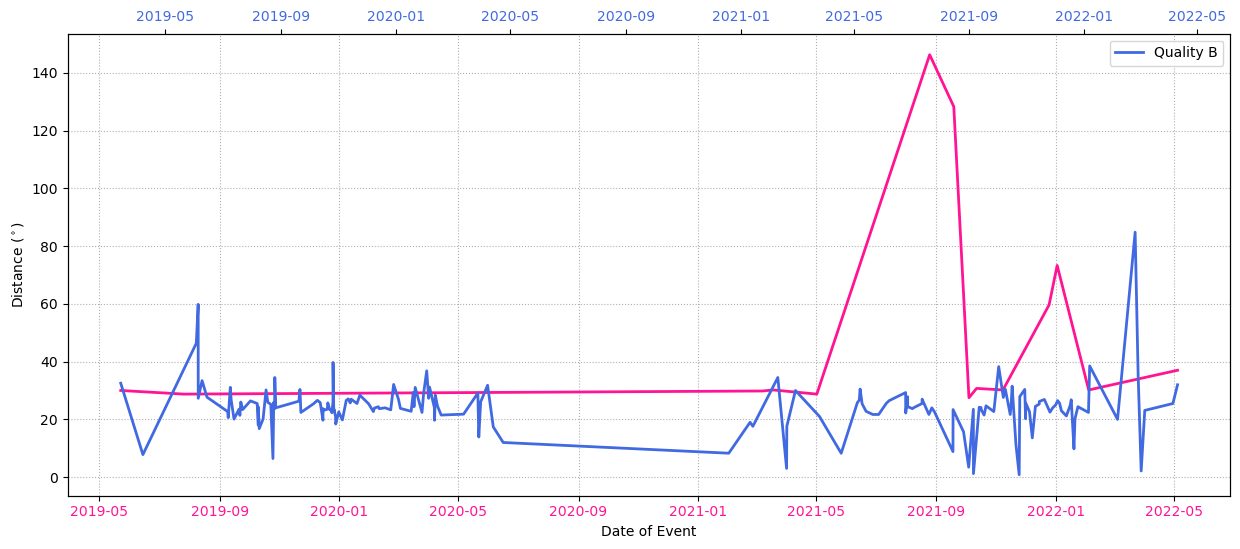

In [20]:
df_a = df_a.sort_values('Timestamp')

df_a_filtered = df_a[df_a['Quality'] == 'A']
df_b_filtered = df_a[df_a['Quality'] == 'B']

quality= df_a.Quality
distance= df_a.Distance

fig, ax1= plt.subplots(figsize=(15,6))

color = 'deeppink'
ax1.plot(df_a_filtered['Timestamp'], df_a_filtered['Distance'], color=color, linewidth=2, label='Quality A')
ax1.set_ylabel(r'Distance ($^\circ$)')
ax1.set_xlabel('Date of Event')
#ax1.set_ylim()
#ax1.invert_yaxis()
ax1.tick_params(axis='x', labelcolor=color)
ax1.grid(ls='dotted', which='both') #dotted grid lines

ax2 = ax1.twiny()
color = 'royalblue'
ax2.plot(df_b_filtered['Timestamp'], df_b_filtered['Distance'], color=color, linewidth=2, label='Quality B')
#ax2.set_xlabel()
ax2.tick_params(axis='x', labelcolor=color)

plt.legend()

plt.show()

In [ ]:
def load_final_marsquakes_df(filename):
    
    cols = ['Event_ID', 'Distance_Degrees', 'Distance_KM', 't0', 'tp', 'ts', 'Vp_Vs_Ratio']
    
    
    df = pd.read_csv(filename, sep=',', names=cols, on_bad_lines='skip', skiprows= 1)

    return df


df_a = load_final_marsquakes_df('final_marsquakes_data_frame.csv')
volatile_zone = df_a[(df_a['Vp_Vs_Ratio'] >= 1.80) & (df_a['Vp_Vs_Ratio'] <= 2.10)].copy()

# depth is ~12% of the surface distance
volatile_zone['Est_Depth_KM'] = volatile_zone['Distance_KM'] * 0.12

#sort into near, farther, farthest away from lander

volatile_zone.head(10)

,Event_ID,Distance_Degrees,Distance_KM,t0,tp,ts,Vp_Vs_Ratio,Est_Depth_KM
8,S0976a,146.26,8658.592,2021-08-25T03:32:20.629953Z,2021-08-25T03:48:58.4Z,2021-08-25T04:03:07.778327Z,1.851277,1039.03104
10,S0820a,30.19,1787.248,2021-03-18T14:51:33.869889Z,2021-03-18T14:54:39.0Z,2021-03-18T14:57:39.0Z,1.972289,214.46976
14,S1197a,31.98,1893.216,2022-04-09T22:05:52.41687Z,2022-04-09T22:09:38.5Z,2022-04-09T22:12:49.0Z,1.842610,227.18592
15,S1192a,25.50,1509.600,2022-04-04T23:06:52.616746Z,2022-04-04T23:12:12.572401Z,2022-04-04T23:16:48.265836Z,1.861661,181.15200
16,S1163a,23.10,1367.520,2022-03-06T02:29:13.668752Z,2022-03-06T02:34:18.697973Z,2022-03-06T02:38:28.753599Z,1.819776,164.10240
23,S1094d,24.40,1444.480,2021-12-25T03:31:41.685086Z,2021-12-25T03:36:52.573319Z,2021-12-25T03:41:16.658691Z,1.849454,173.33760
27,S1086d,24.90,1474.080,2021-12-16T23:02:32.671075Z,2021-12-16T23:07:42.4055Z,2021-12-16T23:12:11.468547Z,1.868690,176.88960
29,S1077c,23.00,1361.600,2021-12-07T14:01:49.15588Z,2021-12-07T14:06:59.285347Z,2021-12-07T14:11:08.381859Z,1.803202,163.39200
30,S1075c,25.60,1515.520,2021-12-05T14:43:47.693762Z,2021-12-05T14:49:10.902171Z,2021-12-05T14:53:48.242672Z,1.858086,181.86240
31,S1073d,26.50,1568.800,2021-12-03T14:28:52.584603Z,2021-12-03T14:33:57.521266Z,2021-12-03T14:38:44.069111Z,1.939696,188.25600


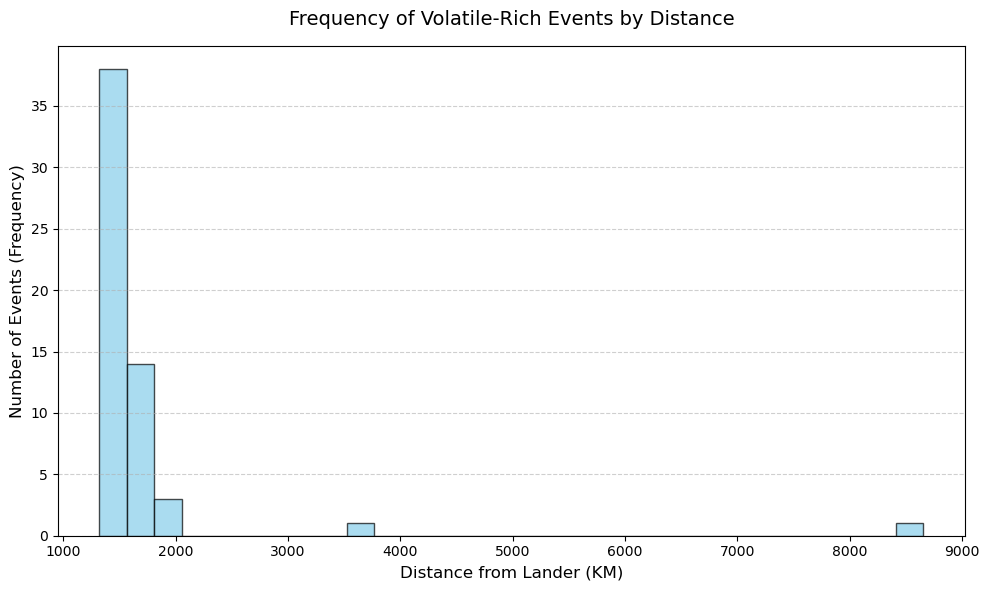

In [ ]:
plt.figure(figsize=(10, 6))

n, bins, patches = plt.hist(volatile_zone['Distance_KM'], 
                            bins=30, 
                            color='skyblue', 
                            edgecolor='black', 
                            alpha=0.7)

plt.title('Frequency of Volatile-Rich Events by Distance', fontsize=14, pad=15)
plt.xlabel('Distance from Lander (KM)', fontsize=12)
plt.ylabel('Number of Events (Frequency)', fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

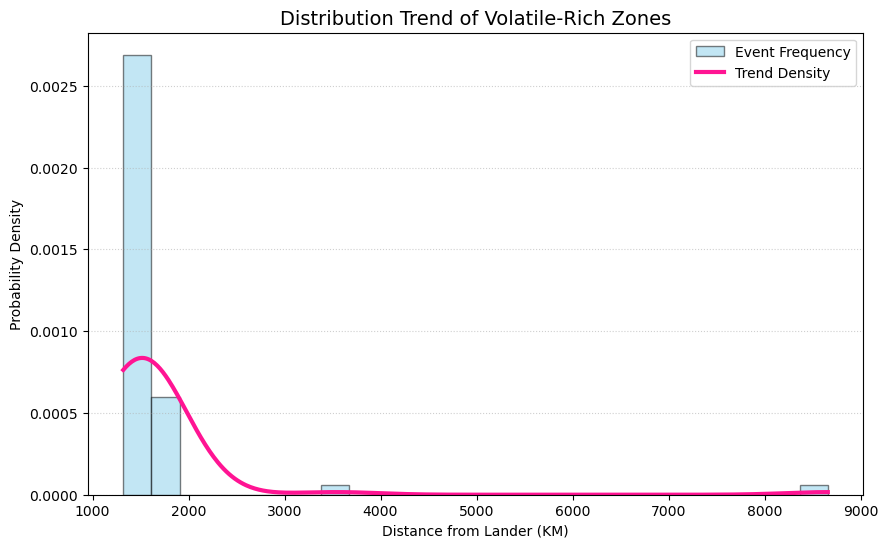

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

dist = volatile_zone['Distance_KM'].values

# 2. Setup Figure
fig, ax1 = plt.subplots(figsize=(10, 6))

n, bins, patches = ax1.hist(dist, bins=25, density=True, color='skyblue', 
                            edgecolor='black', alpha=0.5, label='Event Frequency')

kde = gaussian_kde(dist)
dist_range = np.linspace(min(dist), max(dist), 500) # Smooth X-axis
ax1.plot(dist_range, kde(dist_range), color='deeppink', linewidth=3, label='Trend Density')

ax1.set_title('Distribution Trend of Volatile-Rich Zones', fontsize=14)
ax1.set_xlabel('Distance from Lander (KM)')
ax1.set_ylabel('Probability Density')
ax1.legend()
ax1.grid(axis='y', ls='dotted', alpha=0.6)

plt.show()

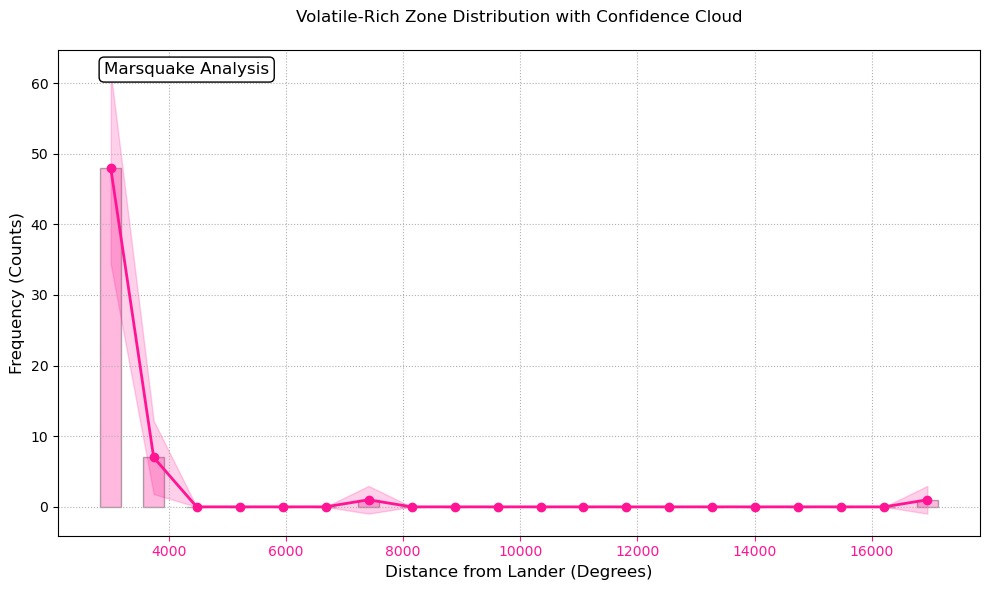

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

dist = volatile_zone['Distance_KM'].values
counts, bin_edges = np.histogram(dist, bins=20)
bin_centers = (bin_edges[:-1] + bin_edges[1:])

z_score = 1.96
ci = z_score * np.sqrt(counts)

fig, ax1 = plt.subplots(figsize=(10, 6))

color = 'deeppink'
ax1.bar(bin_centers, counts, width=np.diff(bin_edges), 
        color=color, alpha=0.3, edgecolor='black', label='Event Frequency')

ax1.plot(bin_centers, counts, color=color, linewidth=2, marker='o')

ax1.fill_between(bin_centers, counts - ci, counts + ci, 
                 color=color, alpha=0.2, label='95% Confidence Interval')

ax1.set_xlabel('Distance from Lander (Degrees)', fontsize=12)
ax1.set_ylabel('Frequency (Counts)', fontsize=12)
ax1.set_title('Volatile-Rich Zone Distribution with Confidence Cloud', pad=20)

ax1.tick_params(axis='x', colors=color)
ax1.grid(ls='dotted', which='both')

ax1.text(0.05, 0.95, 'Marsquake Analysis', transform=ax1.transAxes, fontsize=12,
         bbox=dict(boxstyle='round', facecolor='white', alpha=1))

plt.tight_layout()
plt.show()